## Implementación de CROP3

Compración de PSNR, SSIM y ACC para los modelos crop2, crop3 con delta corrigiendo la fuente 

Usando fashion como dataset


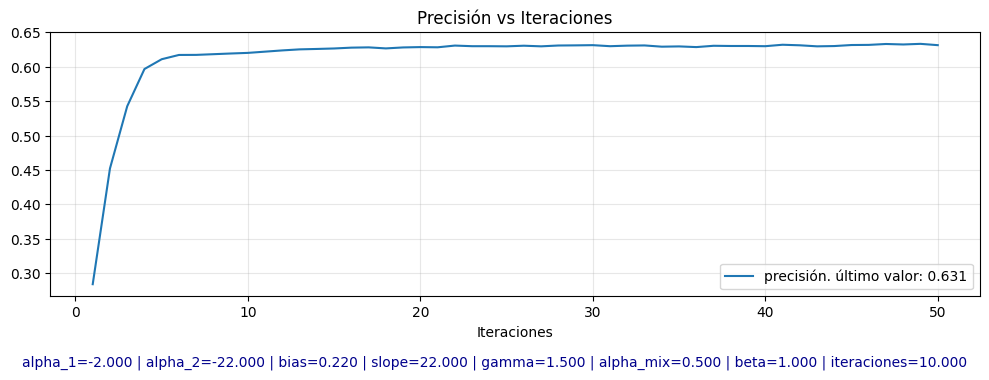

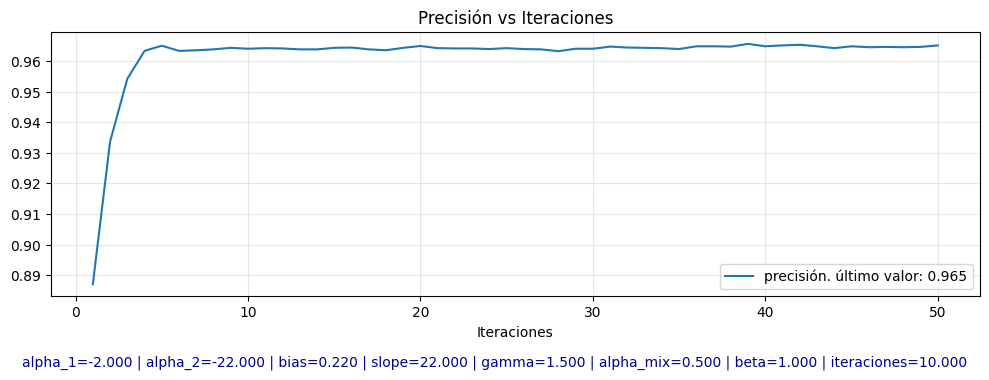

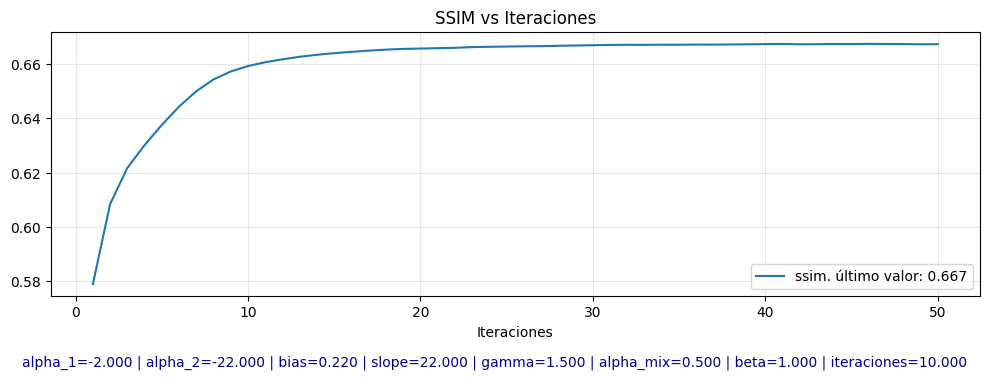

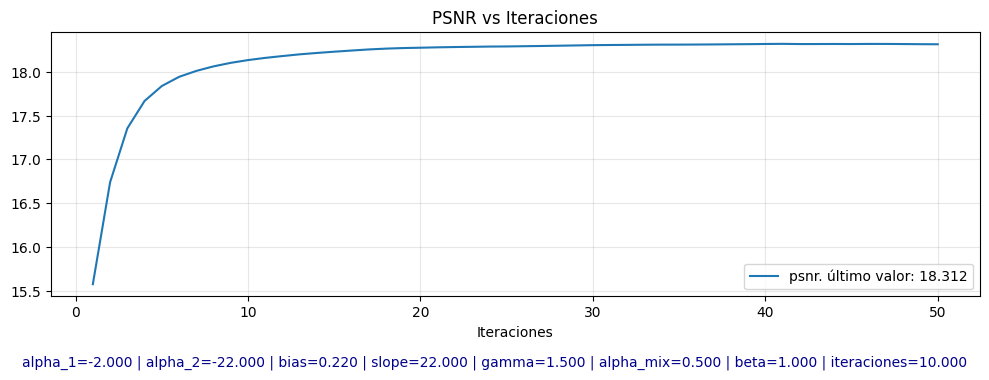


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.500
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.312  std:3.328
mask_bpsnr       : mean: 11.591  std:1.673
ssim             : mean: 0.667  std:0.140
acc_at_least_one : 0.965
acc_both         : 0.631



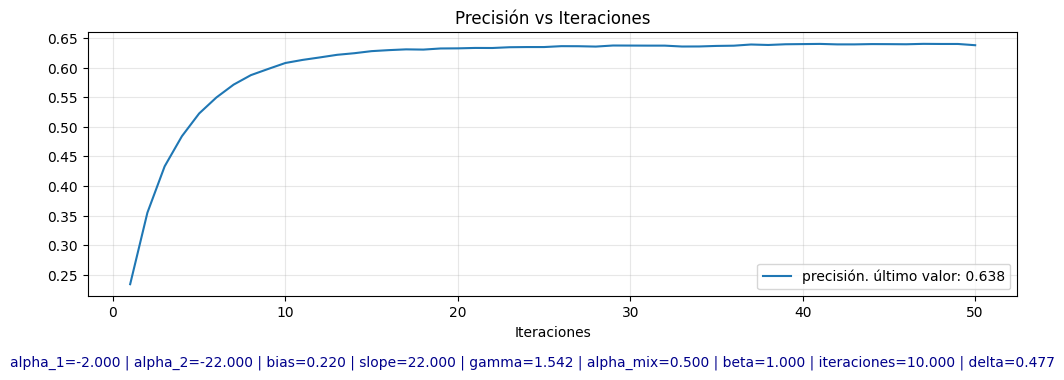

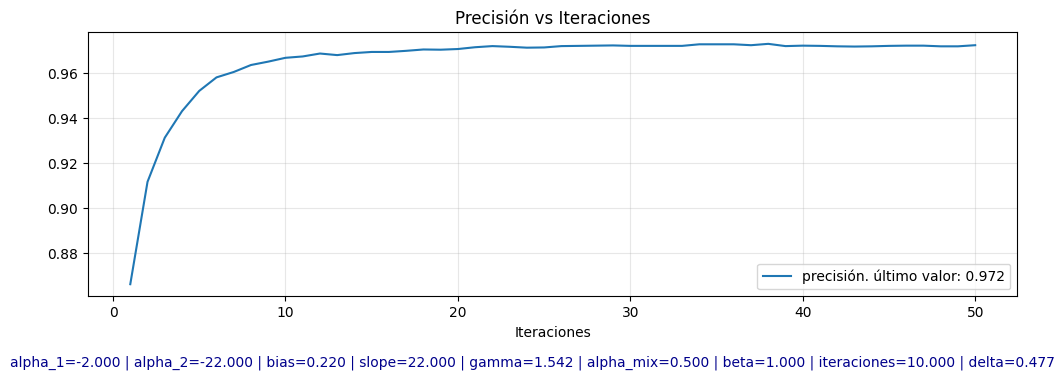

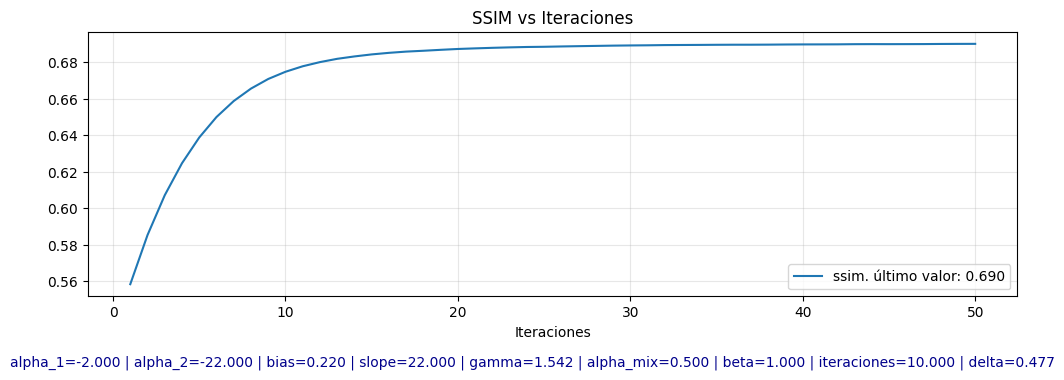

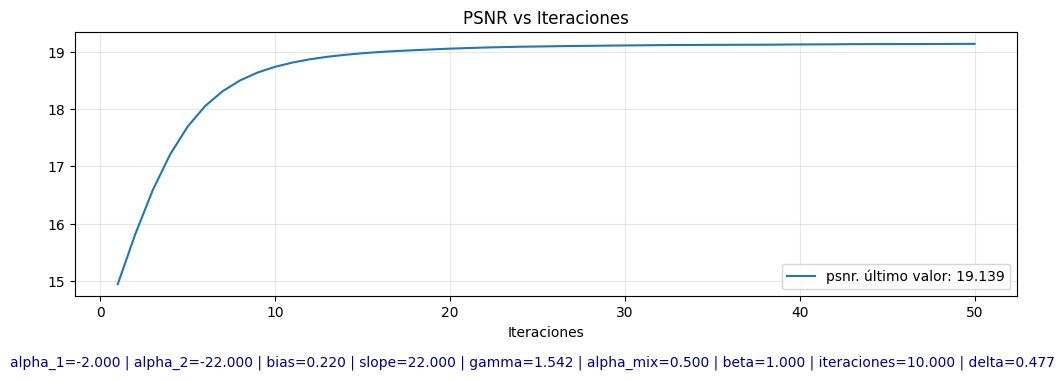


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.542
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.477

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.139  std:3.064
mask_bpsnr       : mean: 11.118  std:1.594
ssim             : mean: 0.690  std:0.107
acc_at_least_one : 0.972
acc_both         : 0.638



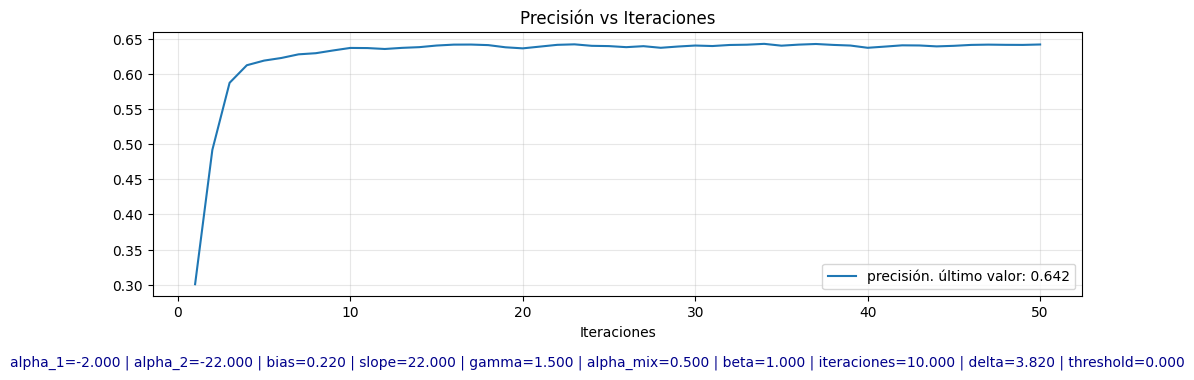

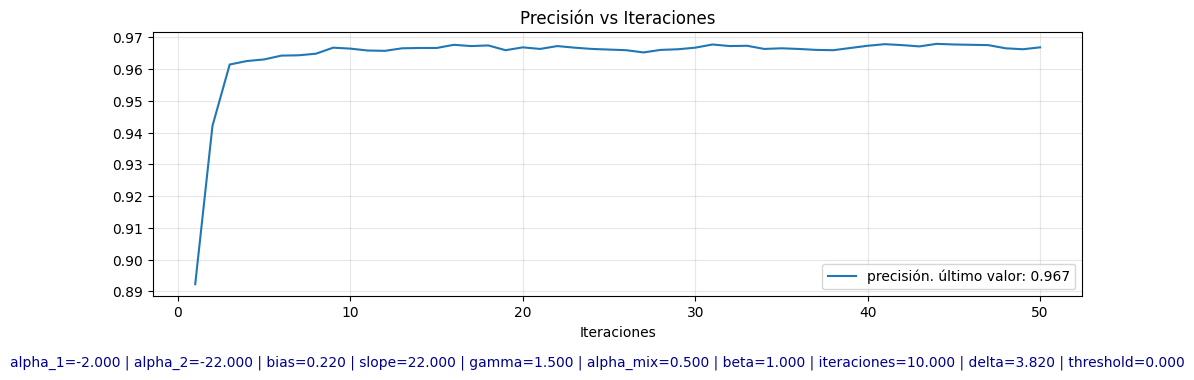

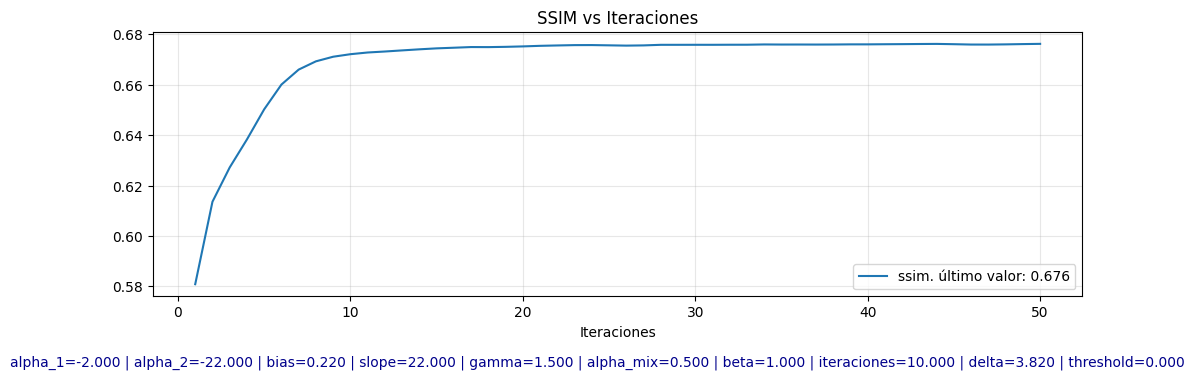

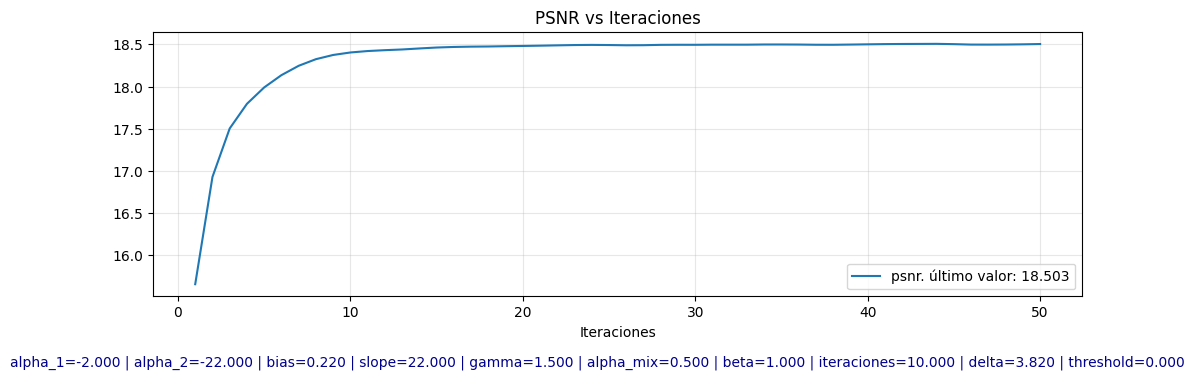


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.500
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 3.820
threshold   : 0.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 18.503  std:3.220
mask_bpsnr       : mean: 12.485  std:1.842
ssim             : mean: 0.676  std:0.134
acc_at_least_one : 0.967
acc_both         : 0.642



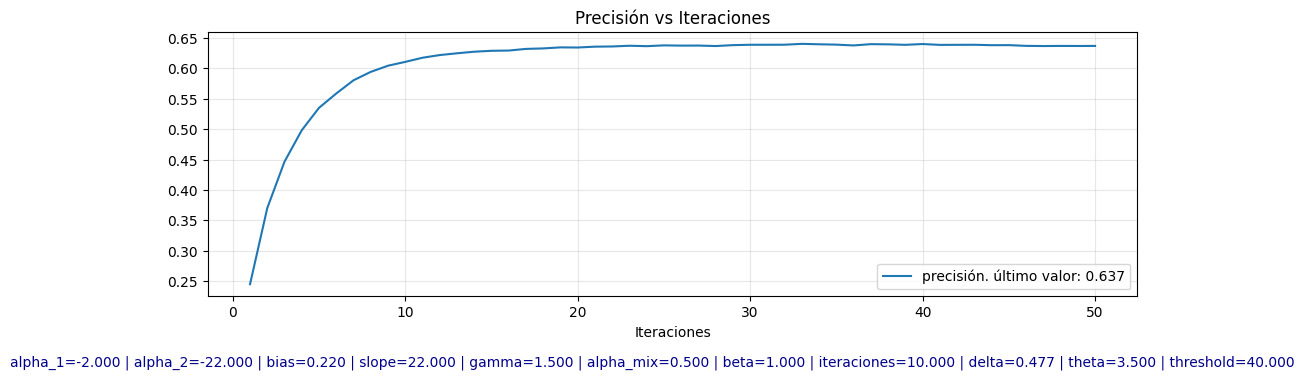

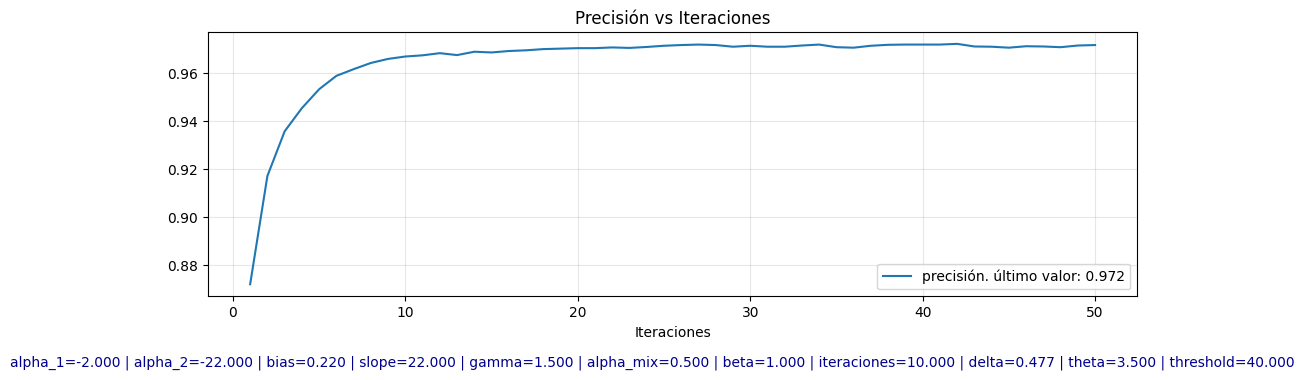

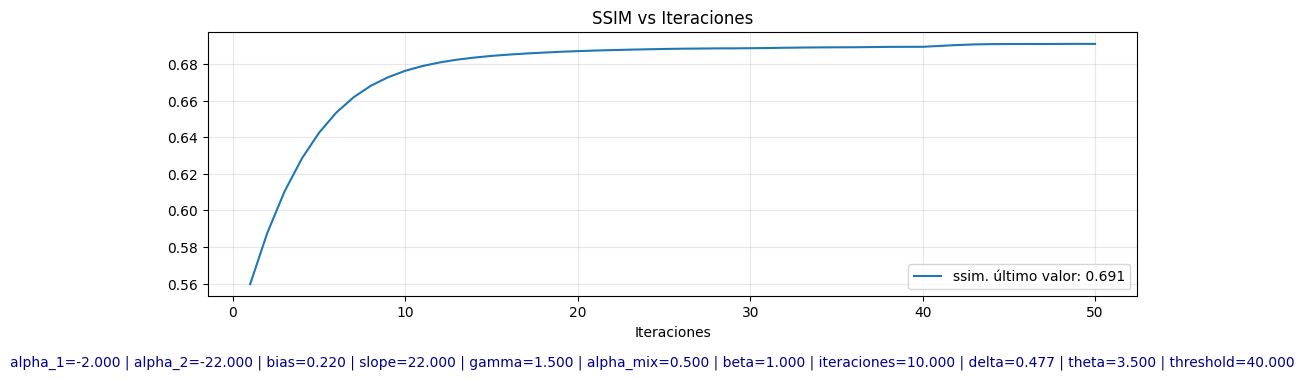

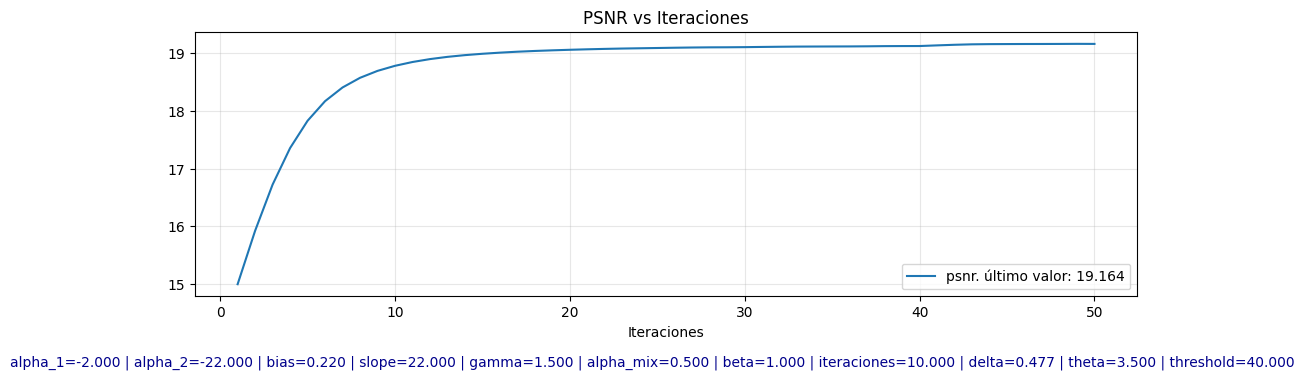


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.500
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.477
theta       : 3.500
threshold   : 40.000

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.164  std:3.048
mask_bpsnr       : mean: 11.952  std:1.615
ssim             : mean: 0.691  std:0.106
acc_at_least_one : 0.972
acc_both         : 0.637



In [18]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


SEED = 1234 #Semilla
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


ITERATIONS =50
N_PICTURES = -1

DATASET = "fashion" # mnist o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]



c2 = Crop2(cvae=cvae,predictor=predictor)


metrics2 = c2.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params={"gamma":1.5},
    show_all_curves=True
    )

c3 = Crop3EstimationCorrection(cvae=cvae,predictor=predictor)


metrics3ec = c3.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params={'gamma': 1.5420520651370637, 'delta': 0.4771720136717561},
    show_all_curves=True
    )


c3 = Crop3MaskCorrection(cvae=cvae,predictor=predictor)


metrics3ms = c3.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params={'gamma': 1.5, 'delta': 3.82,"threshold":0},
    show_all_curves=True
    )


c3 = Crop3AllCorrections(cvae=cvae,predictor=predictor)


metrics3ac = c3.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params={'gamma': 1.5,'delta': 0.4771720136717561 ,'theta': 3.5,"threshold":ITERATIONS-10},
    show_all_curves=True
    )









#mejores parametros para Crop3MaskCorrection  optimizando acc_both.

#params={'gamma': 1.136128192066129, 'delta': -1.7913722978884388}

#mejores parametros para Crop3MaskCorrection  optimizando SSIM.

#params={'gamma': 0.32977989566222726, 'delta': 0.7689584803518953}

#----------------------------------------------------------------------

#mejores parametros para Crop3EstimationCorrection  optimizando acc_both.
#params={'gamma': 1.265852455556597, 'delta': 0.3429787390624981}

#mejores parametros para Crop3EstimationCorrection  optimizando SSIM.
#params={'gamma': 1.5420520651370637, 'delta': 0.4771720136717561}





Usando mnist como dataset


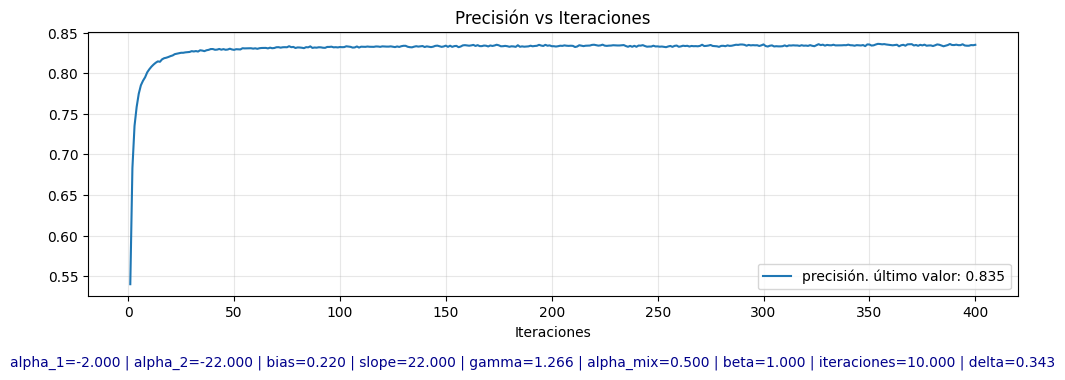

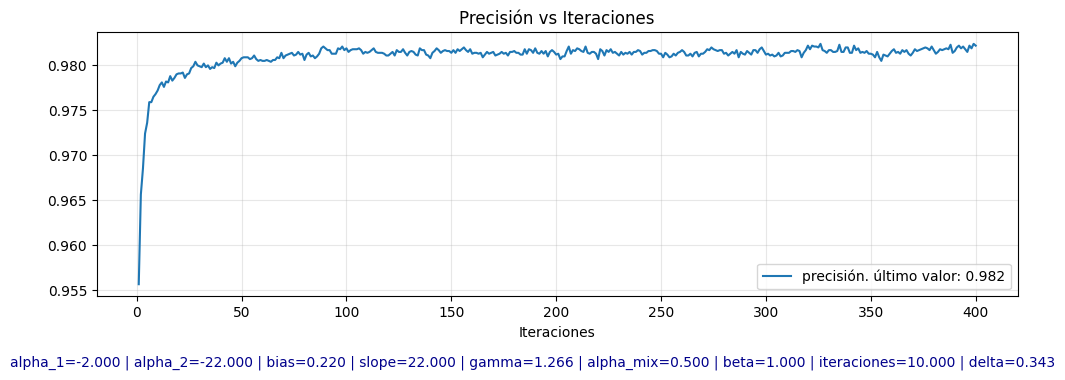

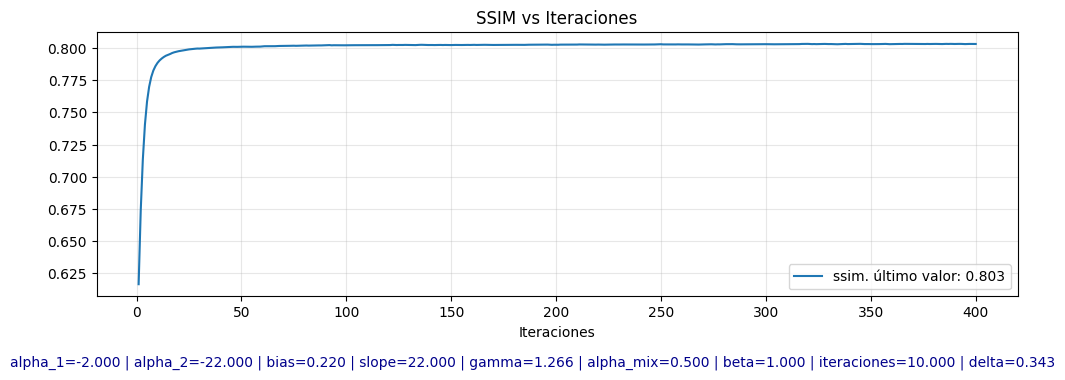

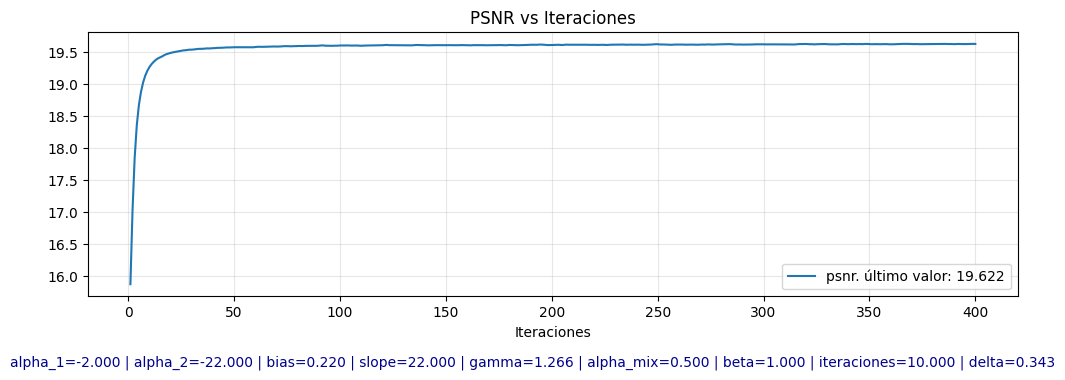


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.266
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.343

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.622  std:3.234
mask_bpsnr       : mean: 13.560  std:1.913
ssim             : mean: 0.803  std:0.107
acc_at_least_one : 0.982
acc_both         : 0.835



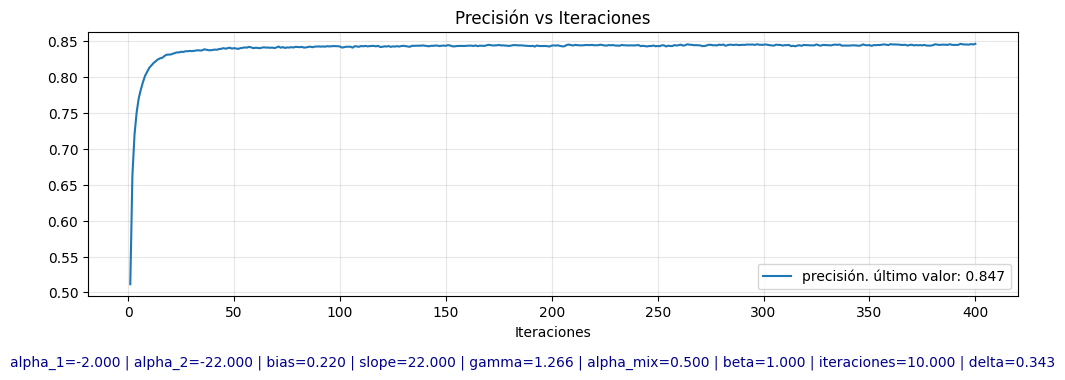

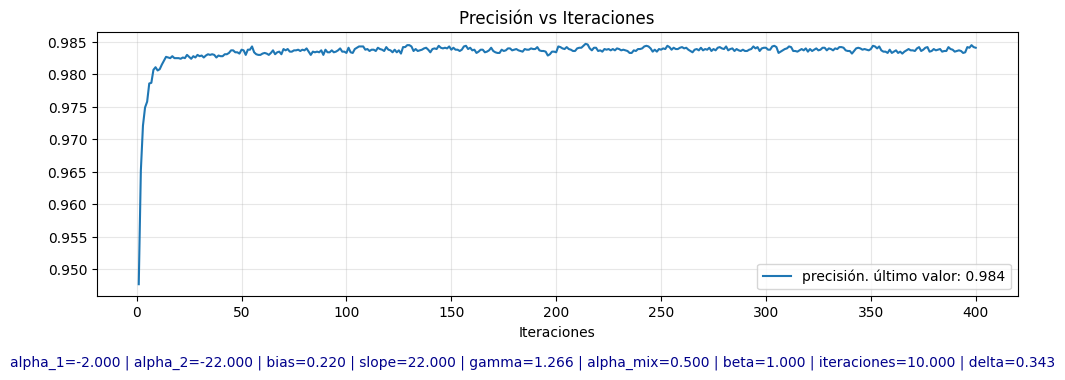

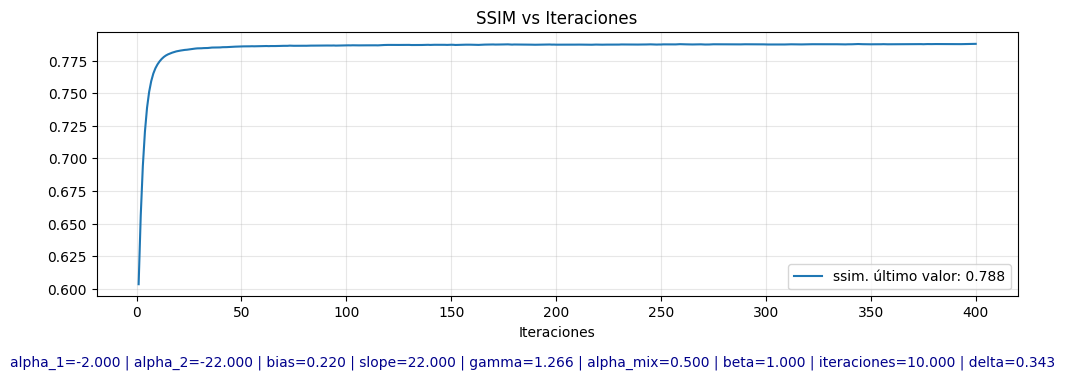

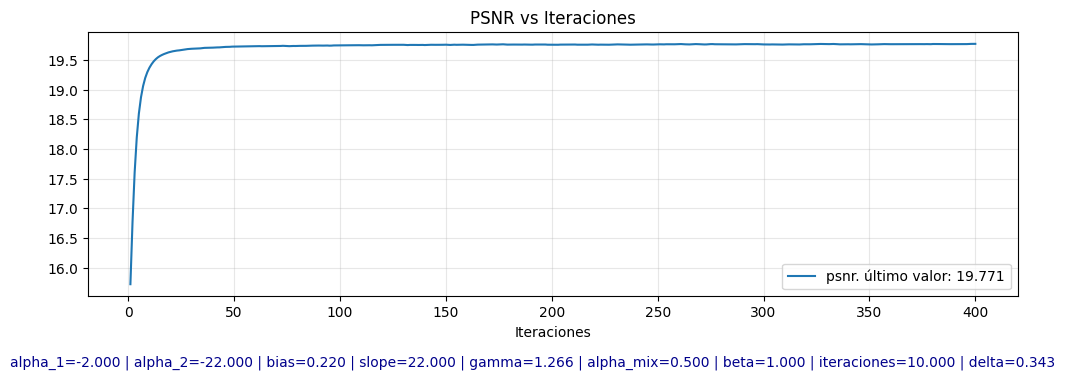


======= PARÁMETROS DEL MODELO =====================
alpha_1     : -2.000
alpha_2     : -22.000
bias        : 0.220
slope       : 22.000
gamma       : 1.266
alpha_mix   : 0.500
beta        : 1.000
iteraciones : 10.000
delta       : 0.343

============= MÉTRICAS ===========================
recon_bpsnr      : mean: 19.771  std:3.068
mask_bpsnr       : mean: 13.380  std:1.841
ssim             : mean: 0.788  std:0.099
acc_at_least_one : 0.984
acc_both         : 0.847



In [11]:

import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))
from project.loader import Loader
from project.metrics.metrics import Metrics 
from project.CROP.models.crop2 import Crop2
from project.CROP.models.crop3_estimation_correction import Crop3EstimationCorrection
from project.CROP.models.crop3_mask_correction import Crop3MaskCorrection
from project.CROP.models.crop3_all_corrections import Crop3AllCorrections
from project.CROP.models.crop3_one_hot import Crop3OH
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random


DATASET = "mnist" # mnist o fashion
LAT = 64
INTER = 128
cvae = Loader.cvae(inter=INTER,lat=LAT,dataset=DATASET)
data = Loader.data(dataset=DATASET)

predictor = Loader.predictor(dataset=DATASET)

ITERATIONS =400
N_PICTURES = -1

x_test = data["x_test"]
x_test_1 = data["x_test_1"]
y_test = data["y_test"]
y_test_1 = data["y_test_1"]
labels= data["labels"]

c2 = Crop2(cvae=cvae,predictor=predictor)


metricas2 = c2.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params={'gamma': 1.265852455556597, 'delta': 0.3429787390624981},
    show_all_curves=True
    )



c3 = Crop3EstimationCorrection(cvae=cvae,predictor=predictor)


metrics3ec = c3.unmix(
    x_test[:N_PICTURES],
    x_test_1[:N_PICTURES],
    y_test[:N_PICTURES],
    y_test_1[:N_PICTURES],
    iterations=ITERATIONS,
    show_image=False,
    labels=labels,
    params={'gamma': 1.265852455556597, 'delta': 0.3429787390624981},
    show_all_curves=True
    )


# c3 = Crop3MaskCorrection(cvae=cvae,predictor=predictor)


# metrics3ms = c3.unmix(
#     x_test[:N_PICTURES],
#     x_test_1[:N_PICTURES],
#     y_test[:N_PICTURES],
#     y_test_1[:N_PICTURES],
#     iterations=ITERATIONS,
#     show_image=True,
#     labels=labels,
#     params={'gamma': 1.5, 'delta': 3.82,"threshold":0},
#     show_all_curves=True
#     )


# c3 = Crop3AllCorrections(cvae=cvae,predictor=predictor)


# metrics3ac = c3.unmix(
#     x_test[:N_PICTURES],
#     x_test_1[:N_PICTURES],
#     y_test[:N_PICTURES],
#     y_test_1[:N_PICTURES],
#     iterations=ITERATIONS,
#     show_image=True,
#     labels=labels,
#     params={'gamma': 1.5,'delta': 0.4771720136717561 ,'theta': 3.5,"threshold":ITERATIONS-10},
#     show_all_curves=True
#    )

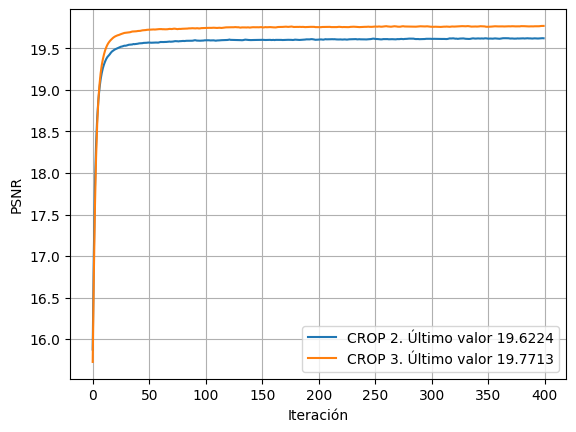

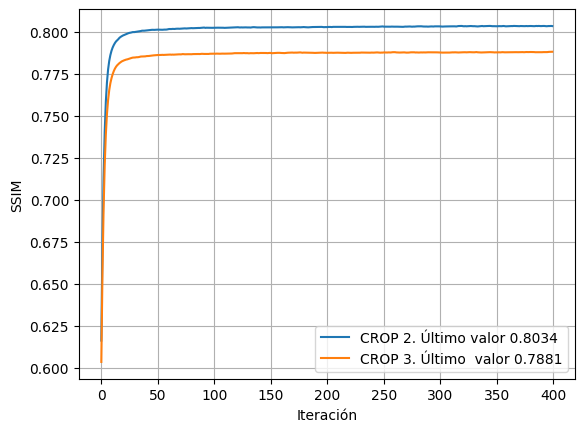

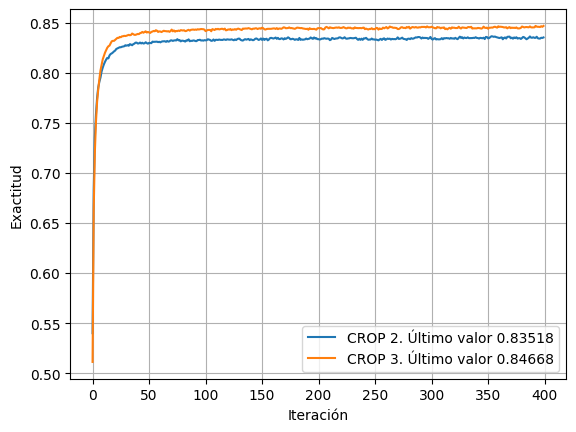

In [12]:
plt.plot(metricas2["psnr_plot"], label=f"CROP 2. Último valor {metricas2['psnr_plot'][-1]:.4f}")
plt.plot(metrics3ec["psnr_plot"], label=f"CROP 3. Último valor {metrics3ec['psnr_plot'][-1]:.4f}")

plt.grid()
plt.xlabel("Iteración")
plt.ylabel("PSNR")
plt.legend()
plt.show()


plt.plot(metricas2["ssim_plot"], label=f"CROP 2. Último valor {metricas2['ssim_plot'][-1]:.4f}")
plt.plot(metrics3ec["ssim_plot"], label=f"CROP 3. Último  valor {metrics3ec['ssim_plot'][-1]:.4f}")

plt.grid()
plt.xlabel("Iteración")
plt.ylabel("SSIM")
plt.legend()
plt.show()



plt.plot(metricas2["acc_both_plot"], label=f"CROP 2. Último valor {metricas2['acc_both_plot'][-1]}")
plt.plot(metrics3ec["acc_both_plot"], label=f"CROP 3. Último valor {metrics3ec['acc_both_plot'][-1]}")

plt.grid()
plt.xlabel("Iteración")
plt.ylabel("Exactitud")
plt.legend()
plt.show()